# 03 - Statistical Analysis (PuneBite Analyzer)

**Objective:** use statistical tests to check whether the patterns we saw in the EDA are real or just chance.
**Input:** `data/processed/restaurants_clean.csv`
**Output:** test results and conclusions for the report
**Syllabus link:** Unit III (sampling, confidence intervals, hypothesis testing: t-test, chi-square, ANOVA; types of analytics); Lab 3.

**Rule used throughout:** significance level alpha = 0.05. If p < 0.05 we reject the null hypothesis (H0).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
ALPHA = 0.05

df = pd.read_csv("../data/processed/restaurants_clean.csv")
rated = df[df["has_rating"]].copy()

# 'popular' = restaurants with enough votes for the rating to be stable (see notebook 02, section 7)
popular = rated[rated["votes"] >= 50].copy()

cols = list(df.columns)
amenity_cols = cols[cols.index("star1_pct") + 1 : cols.index("spam_review_count")]

print("Rated restaurants:", len(rated), "| Popular (>= 50 votes):", len(popular))

Rated restaurants: 7669 | Popular (>= 50 votes): 3012


## 1. Sampling and confidence intervals

Our data is a *sample* of the restaurants listed on Zomato Pune at one point in time. A 95% confidence interval (CI) gives a range in which the true average rating is likely to lie.

In [2]:
def mean_ci(x, conf=0.95):
    x = pd.Series(x).dropna()
    m, se = x.mean(), stats.sem(x)
    lo, hi = stats.t.interval(conf, len(x) - 1, m, se)
    return m, lo, hi

m, lo, hi = mean_ci(rated["rating"])
print(f"Mean rating of Pune restaurants: {m:.3f}  (95% CI: {lo:.3f} to {hi:.3f}, n = {len(rated)})")

Mean rating of Pune restaurants: 3.436  (95% CI: 3.427 to 3.445, n = 7669)


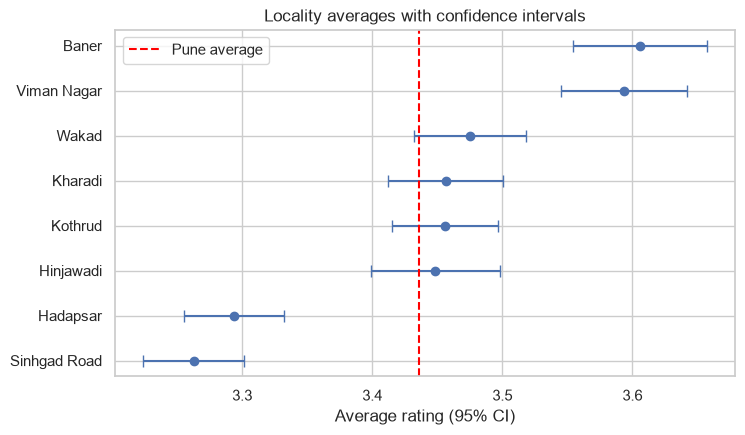

,locality,n,mean,ci_low,ci_high
5,Sinhgad Road,271,3.263,3.224,3.301
1,Hadapsar,309,3.294,3.256,3.332
2,Hinjawadi,307,3.449,3.399,3.498
4,Kothrud,385,3.456,3.415,3.497
3,Kharadi,268,3.456,3.412,3.500
7,Wakad,335,3.475,3.432,3.518
6,Viman Nagar,335,3.593,3.545,3.642
0,Baner,309,3.606,3.554,3.657


In [3]:
# Confidence intervals for the 8 biggest localities: wide interval = less certainty
top8 = rated["locality"].value_counts().head(8).index
ci = pd.DataFrame([(loc, len(g), *mean_ci(g["rating"])) for loc, g in rated[rated["locality"].isin(top8)].groupby("locality")],
                  columns=["locality", "n", "mean", "ci_low", "ci_high"]).sort_values("mean")

plt.figure(figsize=(8, 4.5))
plt.errorbar(ci["mean"], range(len(ci)), xerr=[ci["mean"] - ci["ci_low"], ci["ci_high"] - ci["mean"]], fmt="o", capsize=4)
plt.yticks(range(len(ci)), ci["locality"]); plt.axvline(m, color="red", linestyle="--", label="Pune average")
plt.xlabel("Average rating (95% CI)"); plt.title("Locality averages with confidence intervals"); plt.legend(); plt.show()
ci.round(3)

Intervals that do not overlap the Pune average (for example Baner and Viman Nagar above it, Hadapsar and Sinhgad Road below it) point to real locality differences. We test this formally with the chi-square test in section 5.

## 2. Two-sample t-test: do amenities change ratings?

**H0:** the average rating is the same for restaurants with and without the amenity.
**H1:** the averages are different.

We use **Welch's t-test** (it does not assume equal variances) and double-check with the **Mann-Whitney U test** (no normality assumption). **Cohen's d** measures *how big* the difference is: about 0.2 is small, 0.5 medium, 0.8 large.

In [4]:
def ttest_amenity(data, col):
    a = data.loc[data[col] == 1, "rating"]
    b = data.loc[data[col] == 0, "rating"]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    p_mw = stats.mannwhitneyu(a, b, alternative="two-sided")[1]
    pooled_sd = np.sqrt((a.var() + b.var()) / 2)
    return {"amenity": col, "n_with": len(a), "n_without": len(b),
            "mean_with": a.mean(), "mean_without": b.mean(),
            "t": t, "p_value": p, "p_mannwhitney": p_mw,
            "cohens_d": (a.mean() - b.mean()) / pooled_sd,
            "significant": p < ALPHA}

tested = ["outdoor_seating", "vegetarian_only", "table_booking_recommended", "home_delivery"]
res_all = pd.DataFrame([ttest_amenity(rated, c) for c in tested])
res_all.round(4)

,amenity,n_with,n_without,mean_with,mean_without,t,p_value,p_mannwhitney,cohens_d,significant
0,outdoor_seating,2968,4701,3.4802,3.4081,7.2137,0.0000,0.0000,0.1716,True
1,vegetarian_only,1702,5967,3.4700,3.4263,3.8622,0.0001,0.0000,0.1057,True
2,table_booking_recommended,563,7106,3.8536,3.4029,23.1338,0.0000,0.0000,1.0672,True
3,home_delivery,5733,1936,3.4374,3.4321,0.4681,0.6398,0.0753,0.0125,False


Read this table: `table_booking_recommended` has a huge, very significant difference (d is above 1). `outdoor_seating` and `vegetarian_only` are significant too, but their effect sizes are tiny (d around 0.1 to 0.2). With thousands of rows, even a very small difference becomes "significant", so **significant does not mean important**.

But there is a catch. Restaurants with few votes have low, unstable ratings (notebook 02). If outdoor-seating places simply have more votes, the test could be picking up *popularity* rather than the amenity. Let us repeat the same tests only on restaurants with 50 or more votes.

In [5]:
res_pop = pd.DataFrame([ttest_amenity(popular, c) for c in tested])

compare = res_all[["amenity", "mean_with", "mean_without", "p_value", "cohens_d"]].merge(
    res_pop[["amenity", "mean_with", "mean_without", "p_value", "cohens_d"]],
    on="amenity", suffixes=("_all", "_popular"))
compare.round(4)

,amenity,mean_with_all,mean_without_all,p_value_all,cohens_d_all,mean_with_popular,mean_without_popular,p_value_popular,cohens_d_popular
0,outdoor_seating,3.4802,3.4081,0.0000,0.1716,3.7306,3.7401,0.5329,-0.0227
1,vegetarian_only,3.4700,3.4263,0.0001,0.1057,3.7413,3.7335,0.6413,0.0191
2,table_booking_recommended,3.8536,3.4029,0.0000,1.0672,3.9753,3.6921,0.0000,0.7206
3,home_delivery,3.4374,3.4321,0.6398,0.0125,3.7143,3.8132,0.0000,-0.2297


**What changes when we control for popularity:**
- `outdoor_seating` and `vegetarian_only` lose their significance (p is far above 0.05, d is about 0). Their earlier "effect" was a popularity effect, not a real one.
- `table_booking_recommended` stays strongly significant, so it is a genuine signal (it marks higher-end restaurants).
- `home_delivery` flips: it was not significant overall but becomes slightly *negative* among popular restaurants.

This is a useful lesson for the viva: a test result can disappear (or appear) once you account for a confounding variable.

## 3. Testing every amenity (and why we must correct for it)

If we run 30+ tests at alpha = 0.05, a few will look significant by pure luck. The **Benjamini-Hochberg (FDR) correction** adjusts the p-values for this. The adjusted value is called `q`.

In [6]:
def benjamini_hochberg(p):
    p = np.asarray(p); n = len(p); order = np.argsort(p)
    q = np.empty(n); prev = 1.0
    for rank, i in zip(range(n, 0, -1), order[::-1]):
        prev = min(prev, p[i] * n / rank)
        q[i] = prev
    return q

def test_all_amenities(data, min_group=60):
    rows = []
    for a in amenity_cols:
        if (data[a] == 1).sum() >= min_group and (data[a] == 0).sum() >= min_group:
            rows.append(ttest_amenity(data, a))
    out = pd.DataFrame(rows)
    out["diff"] = out["mean_with"] - out["mean_without"]
    out["q_value"] = benjamini_hochberg(out["p_value"])
    out["significant_after_fdr"] = out["q_value"] < ALPHA
    return out

all_tests = test_all_amenities(rated)
pop_tests = test_all_amenities(popular)
print(f"All rated: {len(all_tests)} amenities tested, {(all_tests.p_value < ALPHA).sum()} with p < 0.05, "
      f"{all_tests.significant_after_fdr.sum()} still significant after FDR correction")
print(f"Popular only: {len(pop_tests)} tested, {(pop_tests.p_value < ALPHA).sum()} with p < 0.05, "
      f"{pop_tests.significant_after_fdr.sum()} still significant after FDR correction")

All rated: 36 amenities tested, 28 with p < 0.05, 28 still significant after FDR correction
Popular only: 31 tested, 25 with p < 0.05, 24 still significant after FDR correction


In [7]:
top = (pop_tests[pop_tests["significant_after_fdr"]]
       .sort_values("diff", ascending=False)
       [["amenity", "n_with", "mean_with", "mean_without", "diff", "cohens_d", "q_value"]])
top.head(10).round(3)

,amenity,n_with,mean_with,mean_without,diff,cohens_d,q_value
20,serves_cocktails,63,4.063,3.728,0.335,0.828,0.0
3,brunch,77,4.042,3.727,0.314,0.802,0.0
18,free_wifi,106,4.037,3.724,0.312,0.830,0.0
4,live_music,207,4.022,3.714,0.307,0.802,0.0
11,live_sports_screening,258,4.005,3.710,0.295,0.803,0.0
25,lgbtqia_friendly,138,4.015,3.722,0.293,0.776,0.0
13,desserts_and_bakes,311,3.990,3.706,0.284,0.764,0.0
29,table_booking_recommended,461,3.975,3.692,0.283,0.721,0.0
10,rooftop,74,4.009,3.729,0.281,0.760,0.0
15,live_entertainment,84,4.006,3.728,0.278,0.751,0.0


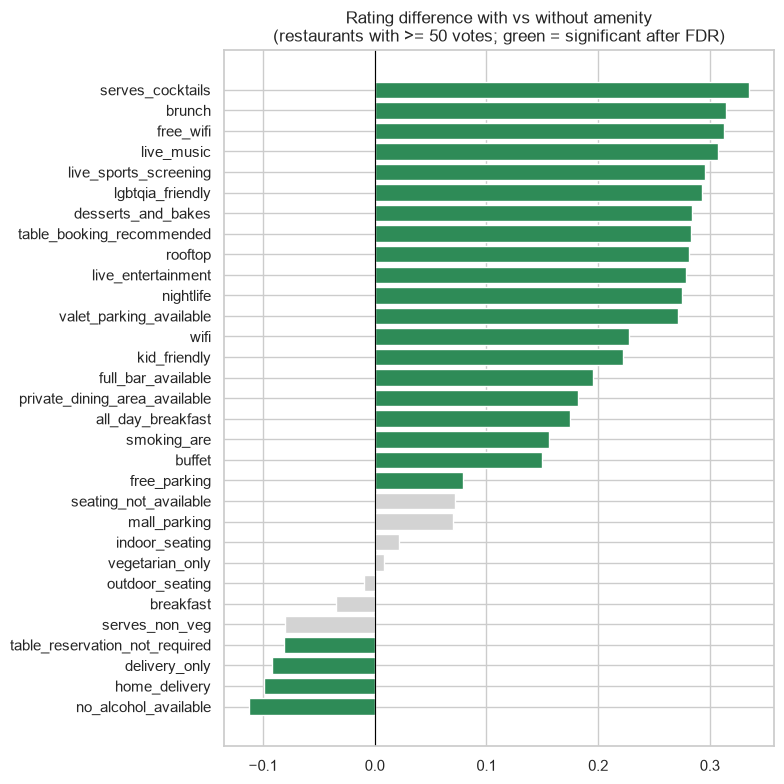

In [8]:
plot = pop_tests.sort_values("diff")
colors = np.where(plot["significant_after_fdr"], "seagreen", "lightgrey")
plt.figure(figsize=(8, 8))
plt.barh(plot["amenity"], plot["diff"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Rating difference with vs without amenity\n(restaurants with >= 50 votes; green = significant after FDR)")
plt.tight_layout(); plt.show()

Even among restaurants with enough votes, premium and experience amenities (cocktails, brunch, live music, live sports screening, table booking, free wifi, rooftop, nightlife) are linked to ratings roughly 0.3 higher. Remember that this shows **association**, not cause.

## 4. One-way ANOVA: does rating differ across restaurant types?

**H0:** all restaurant types have the same average rating.
**H1:** at least one type differs.

We use types with at least 40 rated restaurants. ANOVA assumes equal variances, so we check it with **Levene's test**; if it fails we confirm with the non-parametric **Kruskal-Wallis** test. **Eta-squared** tells how much of the rating variation the type explains.

In [9]:
type_counts = rated["primary_type"].value_counts()
keep_types = list(type_counts[type_counts >= 40].index)
d_types = rated[rated["primary_type"].isin(keep_types)]
groups = [d_types.loc[d_types["primary_type"] == k, "rating"] for k in keep_types]

lev = stats.levene(*groups)
F, p = stats.f_oneway(*groups)
H, p_kw = stats.kruskal(*groups)
ss_between = sum(len(g) * (g.mean() - d_types["rating"].mean()) ** 2 for g in groups)
ss_total = ((d_types["rating"] - d_types["rating"].mean()) ** 2).sum()

print(f"Types compared: {len(keep_types)}")
print(f"Levene (equal variances):  p = {lev.pvalue:.2e}  -> variances {'differ' if lev.pvalue < ALPHA else 'are similar'}")
print(f"ANOVA:                     F = {F:.1f}, p = {p:.2e}")
print(f"Kruskal-Wallis:            H = {H:.1f}, p = {p_kw:.2e}")
print(f"Eta-squared (effect size): {ss_between / ss_total:.3f}  (~{ss_between / ss_total:.0%} of rating variation explained by type)")

Types compared: 13
Levene (equal variances):  p = 1.02e-38  -> variances differ
ANOVA:                     F = 51.5, p = 1.37e-119
Kruskal-Wallis:            H = 516.4, p = 7.16e-103
Eta-squared (effect size): 0.076  (~8% of rating variation explained by type)


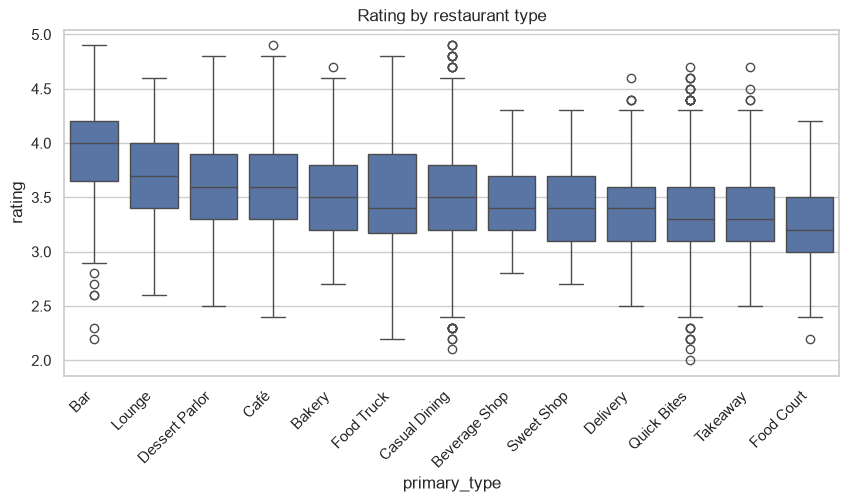

In [10]:
order = d_types.groupby("primary_type")["rating"].mean().sort_values(ascending=False).index
plt.figure(figsize=(10, 4.5))
sns.boxplot(data=d_types, x="primary_type", y="rating", order=order)
plt.xticks(rotation=45, ha="right"); plt.title("Rating by restaurant type"); plt.show()

In [11]:
# Post-hoc: which pairs differ? (Tukey HSD controls the error rate across all pairs)
tk = stats.tukey_hsd(*groups)
pairs = []
for i in range(len(keep_types)):
    for j in range(i + 1, len(keep_types)):
        pairs.append((keep_types[i], keep_types[j], groups[i].mean() - groups[j].mean(), tk.pvalue[i, j]))
pairs = pd.DataFrame(pairs, columns=["type_A", "type_B", "mean_diff_A_minus_B", "p_value"])
print(f"{(pairs.p_value < ALPHA).sum()} of {len(pairs)} pairs differ significantly")
pairs[(pairs.p_value < ALPHA) & ((pairs.type_A == "Bar") | (pairs.type_B == "Bar"))].round(4).head(8)

a:\DSML\PuneBite\.venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


39 of 78 pairs differ significantly


,type_A,type_B,mean_diff_A_minus_B,p_value
6,Quick Bites,Bar,-0.5284,0.0
17,Casual Dining,Bar,-0.4070,0.0
27,Takeaway,Bar,-0.5482,0.0
36,Delivery,Bar,-0.4707,0.0
44,Café,Bar,-0.2610,0.0
51,Dessert Parlor,Bar,-0.2516,0.0
57,Bakery,Bar,-0.3513,0.0
63,Bar,Food Court,0.6165,0.0


In [12]:
# Same question for price: five equal-sized price bands
rated["price_band"] = pd.qcut(rated["cost_capped"], 5, duplicates="drop")
g_price = [g["rating"].values for _, g in rated.groupby("price_band", observed=True)]
F2, p2 = stats.f_oneway(*g_price)
print(f"Price bands ANOVA: F = {F2:.1f}, p = {p2:.2e}")
rated.groupby("price_band", observed=True)["rating"].agg(["count", "mean"]).round(3)

Price bands ANOVA: F = 198.6, p = 2.87e-162


,count,mean
price_band,,
"(99.999, 300.0]",2217,3.372
"(300.0, 400.0]",2135,3.361
"(400.0, 450.0]",270,3.354
"(450.0, 700.0]",1775,3.416
"(700.0, 2000.0]",1272,3.717


**Conclusion:** restaurant type clearly matters (p is tiny, and Kruskal-Wallis agrees), and it explains roughly 8% of rating variation, a small-to-medium effect. Price also matters, but the pattern is a jump for the most expensive band, not a steady rise.

## 5. Chi-square test of independence: locality vs rating tier

We turn the rating into three tiers: **low** (3.0 or below), **mid** (above 3.0 up to 3.5) and **high** (above 3.5), and compare the 8 biggest localities.

**H0:** rating tier is independent of locality.
**H1:** rating tier depends on locality.

In [13]:
top8 = rated["locality"].value_counts().head(8).index
d_loc = rated[rated["locality"].isin(top8)].copy()
d_loc["tier"] = pd.cut(d_loc["rating"], [0, 3.0, 3.5, 5.0], labels=["low", "mid", "high"])

observed = pd.crosstab(d_loc["locality"], d_loc["tier"])
chi2, p, dof, expected = stats.chi2_contingency(observed)
cramers_v = np.sqrt(chi2 / (observed.values.sum() * (min(observed.shape) - 1)))

print(f"Chi-square = {chi2:.1f}, dof = {dof}, p = {p:.2e}")
print(f"Smallest expected count = {expected.min():.1f} (rule of thumb: should be >= 5)")
print(f"Cramer's V = {cramers_v:.2f}  (about 0.1 small, 0.3 medium, 0.5 large)")

observed

Chi-square = 180.6, dof = 14, p = 4.95e-31
Smallest expected count = 42.2 (rule of thumb: should be >= 5)
Cramer's V = 0.19  (about 0.1 small, 0.3 medium, 0.5 large)


tier,low,mid,high
locality,,,
Baner,39,101,169
Hadapsar,74,173,62
Hinjawadi,56,132,119
Kharadi,29,138,101
Kothrud,54,187,144
Sinhgad Road,73,140,58
Viman Nagar,36,115,184
Wakad,36,167,132


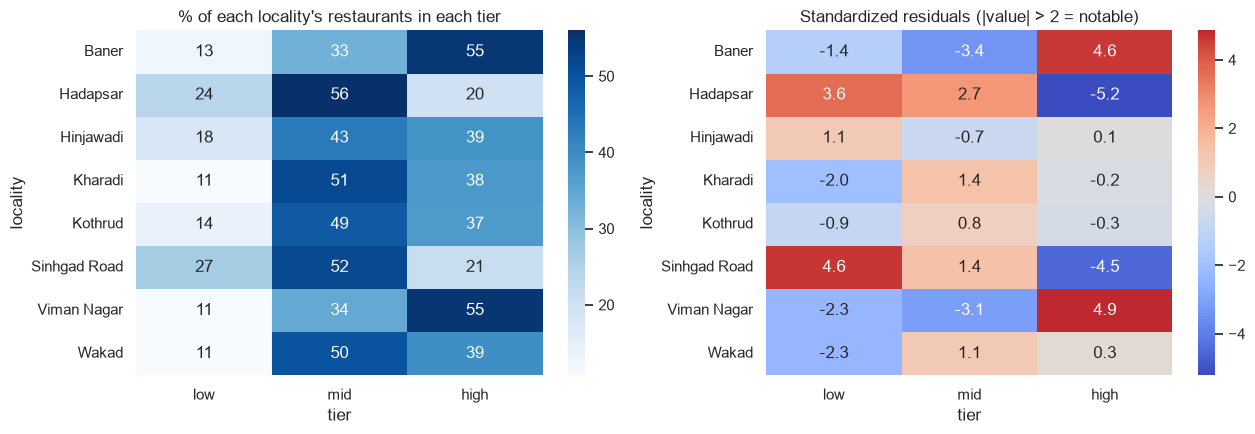

In [14]:
# Row percentages and standardized residuals show WHERE the difference comes from
row_pct = observed.div(observed.sum(axis=1), axis=0) * 100
resid = (observed - expected) / np.sqrt(expected)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(row_pct, annot=True, fmt=".0f", cmap="Blues", ax=ax[0]); ax[0].set_title("% of each locality's restaurants in each tier")
sns.heatmap(resid, annot=True, fmt=".1f", cmap="coolwarm", center=0, ax=ax[1]); ax[1].set_title("Standardized residuals (|value| > 2 = notable)")
plt.tight_layout(); plt.show()

In [15]:
# Robustness check: does the result survive when we use only popular restaurants (>= 50 votes)?
d_pop = d_loc[d_loc["votes"] >= 50]
chi2_p, p_p, dof_p, _ = stats.chi2_contingency(pd.crosstab(d_pop["locality"], d_pop["tier"]))
print(f"Popular only: chi-square = {chi2_p:.1f}, dof = {dof_p}, p = {p_p:.2e}")

Popular only: chi-square = 68.4, dof = 14, p = 3.76e-09


**Conclusion:** we reject H0. Locality and rating tier are related (Cramer's V about 0.19, a small-to-moderate link). Baner and Viman Nagar have a much higher share of high-tier restaurants, while Hadapsar and Sinhgad Road have far more low-tier ones. The result also holds when we use only restaurants with 50 or more votes, so it is not just a popularity artifact.

## 6. Types of analytics in this project

| Type | Question | Where in the project |
|---|---|---|
| **Descriptive** | What happened? | Notebook 02 (EDA, pivot tables, charts) |
| **Diagnostic** | Why did it happen? | This notebook (t-test, ANOVA, chi-square, popularity check) |
| **Predictive** | What will happen? | Notebooks 04 and 05 (classification, regression) |
| **Prescriptive** | What should we do? | Hidden Gems finder and locality report card in the dashboard |

## 7. Summary of results (for the report)

| Test | Question | Result | Practical meaning |
|---|---|---|---|
| 95% CI | Average Pune rating | 3.44 (about 3.43 to 3.45) | Very precise estimate |
| t-test | Table booking vs rating | Significant, d > 1 | Real and large (higher-end places) |
| t-test | Outdoor seating / vegetarian only | Significant overall, **not** after controlling for votes | Popularity effect, not a real one |
| FDR-corrected t-tests | 30+ amenities | Most experience/premium amenities significant | Associated with ratings about 0.3 higher |
| ANOVA + Tukey | Rating across restaurant types | Significant, explains about 8% of variation | Bars, lounges, cafes beat quick-bites |
| ANOVA | Rating across price bands | Significant | Top price band stands out |
| Chi-square | Locality vs rating tier | Significant, V about 0.19 | Location matters |

**Key lesson:** always look at effect size, and always check for confounders (here, vote count), before claiming a feature "improves" ratings.

**Next:** `04_classification.ipynb`. Important for modelling: `votes` is strongly tied to rating, so we must decide carefully how to use it.